# Week 3: Exploratory Data Analysis (EDA)
This notebook analyzes the unified CASCADE2VEC dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Configure plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data
data_path = '../data/processed/phase2_ingestion/unified.parquet'
df = pd.read_parquet(data_path)
print(f"Loaded {len(df)} tweets.")
display(df.head())

Loaded 102440 tweets.


,tweet_id,user_id,timestamp,text,parent_id,cascade_id,event_id,label
0,581287108607811584,72882689,0,BREAKING GERMAN NEWS: Germanwings Airbus Co-Pi...,None,581287108607811584,germanwings-crash,rumour
1,581295747762618368,2221404181,2059,@lodisilverado @sonofliberty357 \n Now expect...,581293754893537280,581287108607811584,germanwings-crash,rumour
2,581287965646688256,2863774500,204,@SonofLiberty357 @gatewaypundit I puspected as...,581287108607811584,581287108607811584,germanwings-crash,rumour
3,581292265118806016,71545482,1229,@SonofLiberty357 @lyonspride121 @gatewaypundit...,581287108607811584,581287108607811584,germanwings-crash,rumour
4,581294271476551680,846330048,1707,@SonofLiberty357 @gatewaypundit Bets off.. I w...,581287108607811584,581287108607811584,germanwings-crash,rumour


## 1. Class Balance
Analyzing the distribution of the target labels.

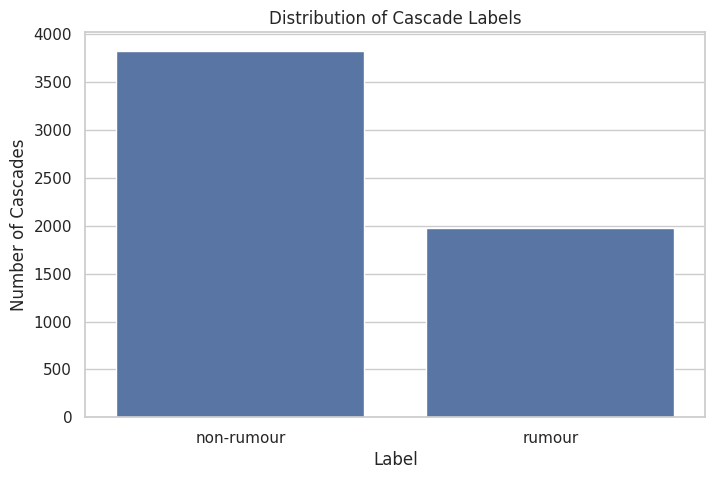

Percentage:
 label
non-rumour    66.01172
rumour        33.98828
Name: proportion, dtype: float64


In [2]:
# Cascade-level label distribution
cascade_labels = df.drop_duplicates(subset=['cascade_id'])[['cascade_id', 'label']]
plt.figure(figsize=(8, 5))
sns.countplot(data=cascade_labels, x='label', order=cascade_labels['label'].value_counts().index)
plt.title("Distribution of Cascade Labels")
plt.ylabel("Number of Cascades")
plt.xlabel("Label")
plt.show()

print("Percentage:\n", cascade_labels['label'].value_counts(normalize=True) * 100)

## 2. Cascade Size Distribution
How many tweets are in each cascade?

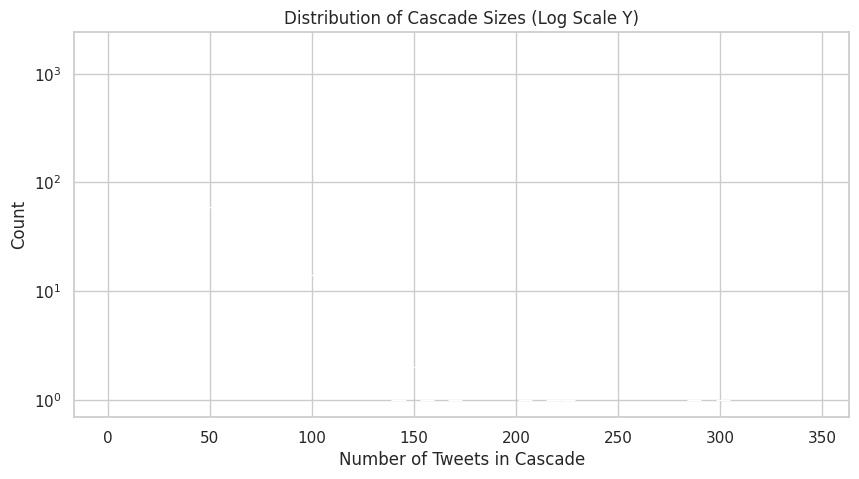

count    5802.000000
mean       17.655981
std        20.051964
min         1.000000
25%         7.000000
50%        14.000000
75%        21.000000
max       346.000000
Name: size, dtype: float64

In [3]:
cascade_sizes = df.groupby('cascade_id').size().reset_index(name='size')
plt.figure(figsize=(10, 5))
sns.histplot(cascade_sizes['size'], bins=50, log_scale=(False, True))
plt.title("Distribution of Cascade Sizes (Log Scale Y)")
plt.xlabel("Number of Tweets in Cascade")
plt.ylabel("Count")
plt.show()
display(cascade_sizes['size'].describe())

## 3. Temporal Spread
How fast do cascades grow over time?

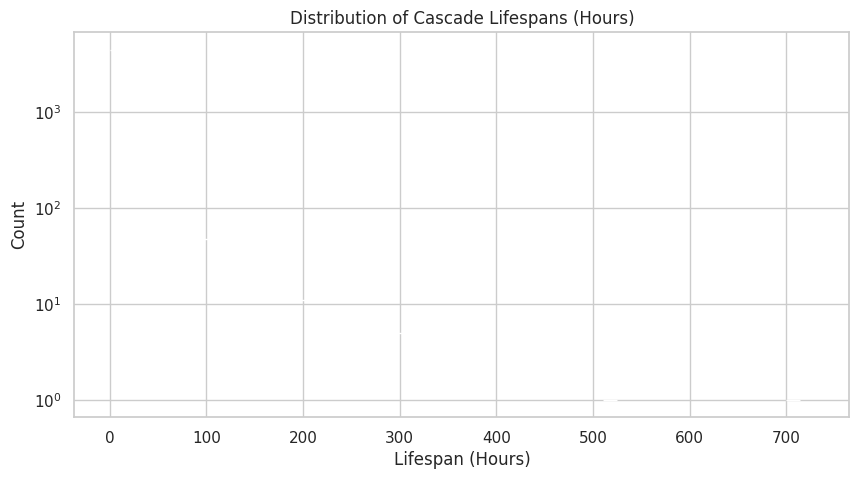

In [4]:
# Max timestamp per cascade (lifespan in seconds)
cascade_lifespans = df.groupby('cascade_id')['timestamp'].max().reset_index(name='lifespan_sec')
cascade_lifespans['lifespan_hours'] = cascade_lifespans['lifespan_sec'] / 3600

plt.figure(figsize=(10, 5))
sns.histplot(cascade_lifespans['lifespan_hours'], bins=50, log_scale=(False, True))
plt.title("Distribution of Cascade Lifespans (Hours)")
plt.xlabel("Lifespan (Hours)")
plt.ylabel("Count")
plt.show()

## 4. Graph Topology EDA
Analyzing graph-level metrics like degree distribution, depth, and branching factor.

In [5]:
def analyze_cascade_graph(cascade_df):
    G = nx.DiGraph()
    
    # Add nodes
    for _, row in cascade_df.iterrows():
        G.add_node(row['tweet_id'], timestamp=row['timestamp'])
        
    # Add edges
    for _, row in cascade_df.iterrows():
        if row['parent_id'] is not None and row['parent_id'] in G.nodes:
            G.add_edge(row['parent_id'], row['tweet_id'])
            
    # Metrics
    degrees = [d for n, d in G.degree()]
    avg_degree = np.mean(degrees) if degrees else 0
    
    # Connected components
    num_components = nx.number_weakly_connected_components(G)
    
    # Root node verification
    roots = [n for n, d in G.in_degree() if d == 0]
    
    # Maximum depth (longest path from root)
    max_depth = 0
    if roots:
        lengths = nx.single_source_shortest_path_length(G, roots[0])
        max_depth = max(lengths.values()) if lengths else 0
        
    return {
        'avg_degree': avg_degree,
        'max_depth': max_depth,
        'num_components': num_components,
        'num_roots': len(roots)
    }

# Sample a subset of cascades for faster graph processing
sample_cascades = cascade_labels['cascade_id'].sample(min(1000, len(cascade_labels)), random_state=42)
sample_df = df[df['cascade_id'].isin(sample_cascades)]

graph_metrics = []
for cid, group in sample_df.groupby('cascade_id'):
    metrics = analyze_cascade_graph(group)
    metrics['cascade_id'] = cid
    graph_metrics.append(metrics)

metrics_df = pd.DataFrame(graph_metrics)
print("Graph Topology Summary (Sampled 1000 cascades):")
display(metrics_df.describe())

Graph Topology Summary (Sampled 1000 cascades):


,avg_degree,max_depth,num_components,num_roots
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.620785,3.347000,1.200000,1.200000
std,0.513114,3.810658,0.791598,0.791598
min,0.000000,0.000000,1.000000,1.000000
25%,1.600000,1.000000,1.000000,1.000000
50%,1.818182,2.000000,1.000000,1.000000
75%,1.900000,4.000000,1.000000,1.000000
max,1.987805,23.000000,13.000000,13.000000
